# Composition And Add

This notebook is the second step in the operator sequence. The first notebook introduced unary decompositions one at a time. Here we keep the same small graph and show how unary operators become useful once you compose them into pipelines or add them together into a larger vocabulary.

Previous: [01 Unary Decompositions](./example_abstract_graph_operators_01_unary_decompositions.ipynb)  
Next: [03 Merge And Complements](./example_abstract_graph_operators_03_merge_and_complements.ipynb)


## What you will see

We will focus on four ideas:

1. `compose(...)` applies operators from right to left.
2. `forward_compose(...)` applies operators from left to right.
3. Order matters because later operators act on the output of earlier ones.
4. `add(...)` runs several decompositions on the same input and unions the results.


In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import networkx as nx
from IPython.core.display import HTML
from warnings import simplefilter

simplefilter(action='ignore', category=FutureWarning)
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')


In [3]:
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.display import display, display_decomposition_graph, display_graph, display_mappings
from abstractgraph.operators import *


def draw(graph, decomposition_function, *, nbits=11, size=(12, 6), n_elements_per_row=8):
    display_decomposition_graph(decomposition_function)
    ag = graph_to_abstract_graph(graph, decomposition_function=decomposition_function, nbits=nbits)
    display(ag, size=size)
    display_mappings(ag, n_elements_per_row=n_elements_per_row)
    return ag


## The same toy graph

We reuse the small graph from notebook 01 so the new behavior comes from the operators, not from a different example.


Graph with 8 nodes and 9 edges


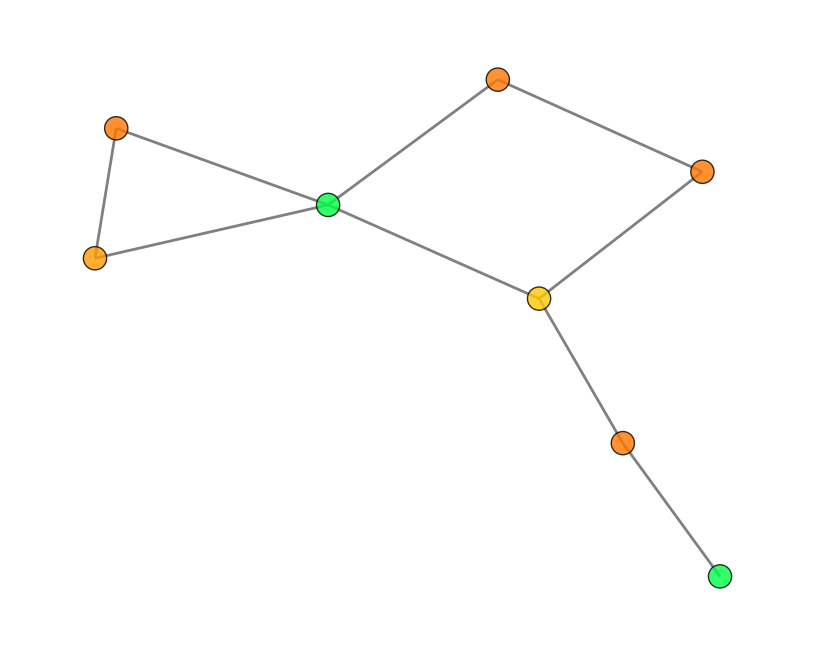

In [4]:
graph = nx.Graph()
graph.add_nodes_from([
    (0, {'label': 'C'}),
    (1, {'label': 'C'}),
    (2, {'label': 'O'}),
    (3, {'label': 'N'}),
    (4, {'label': 'C'}),
    (5, {'label': 'S'}),
    (6, {'label': 'C'}),
    (7, {'label': 'O'}),
])
graph.add_edges_from([
    (0, 1), (1, 2), (2, 3), (3, 0),
    (2, 4), (4, 5), (5, 2),
    (3, 6), (6, 7),
])

print(graph)
display_graph(graph)


## `compose(...)` reads right to left

In `compose(intersection_edges(), node())`, the `node()` decomposition runs first. Then `intersection_edges()` adds interpretation-graph edges between node mapped subgraphs that overlap in the base graph.


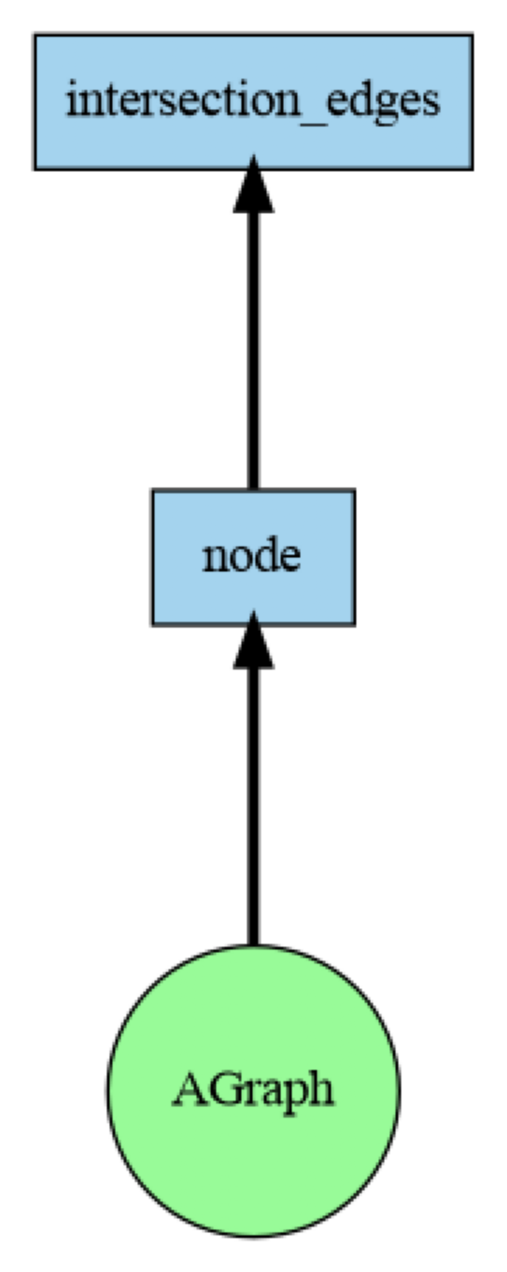

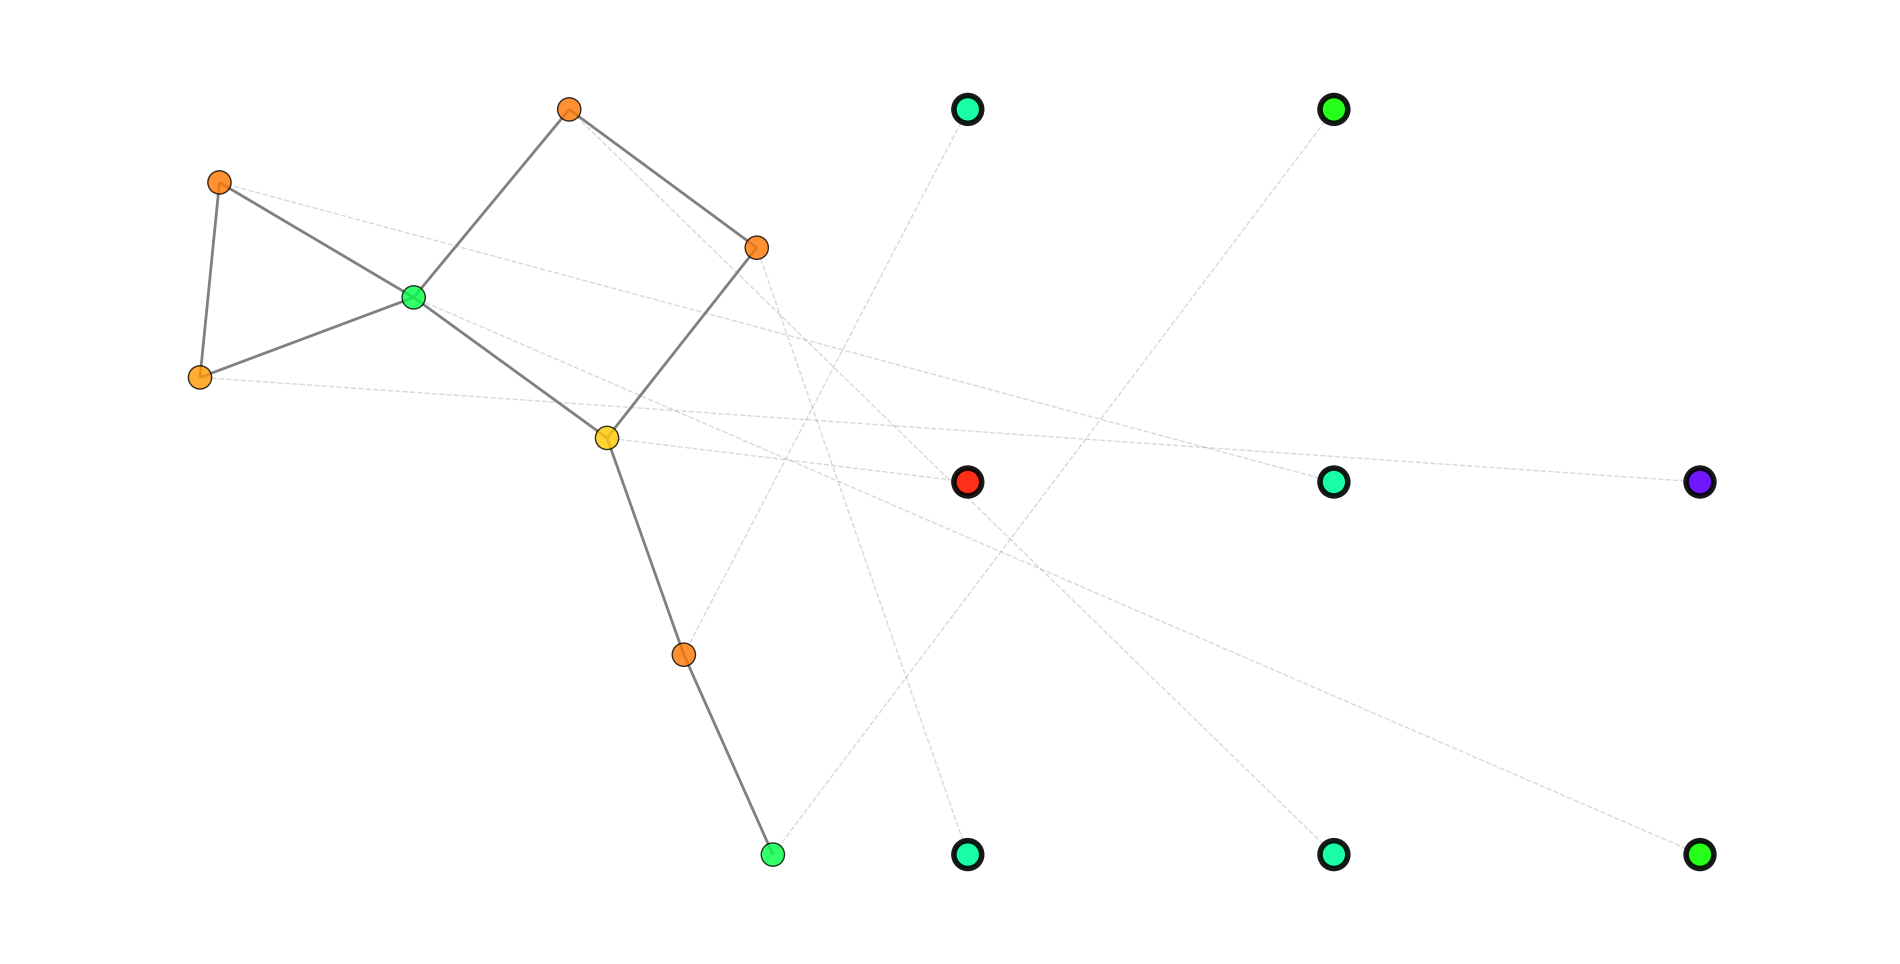

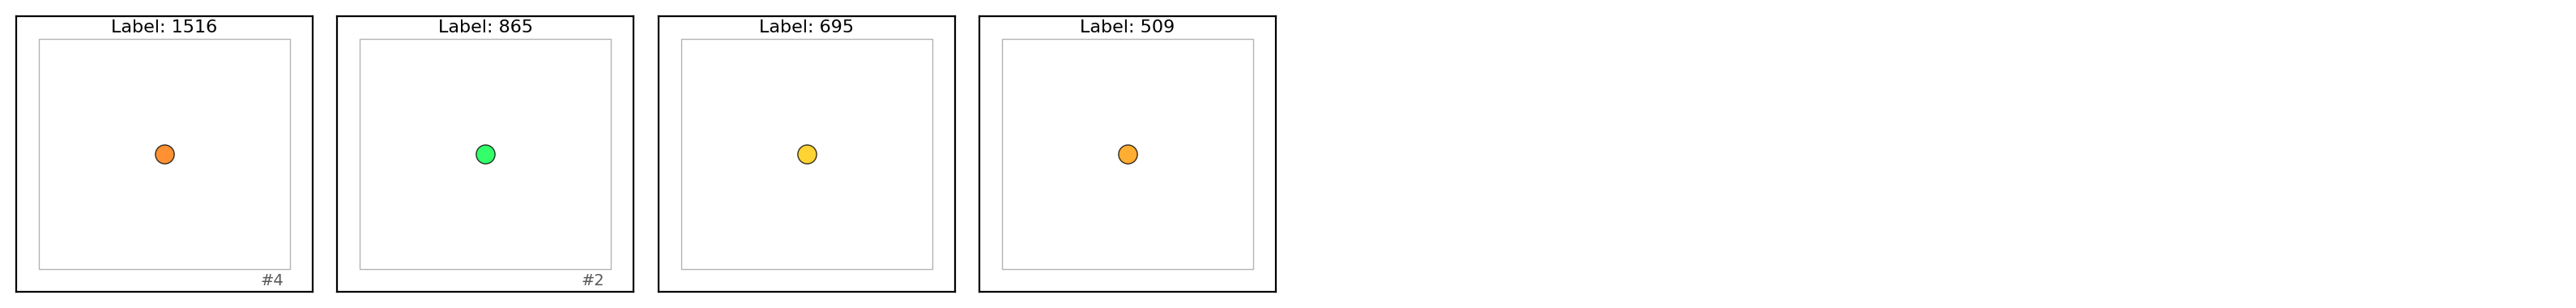

In [5]:
df = compose(intersection_edges(), node())
compose_node_ag = draw(graph, df)


## `forward_compose(...)` reads left to right

The next pipeline expresses the same intent in forward order: first build node mapped subgraphs, then connect overlapping interpretation nodes.


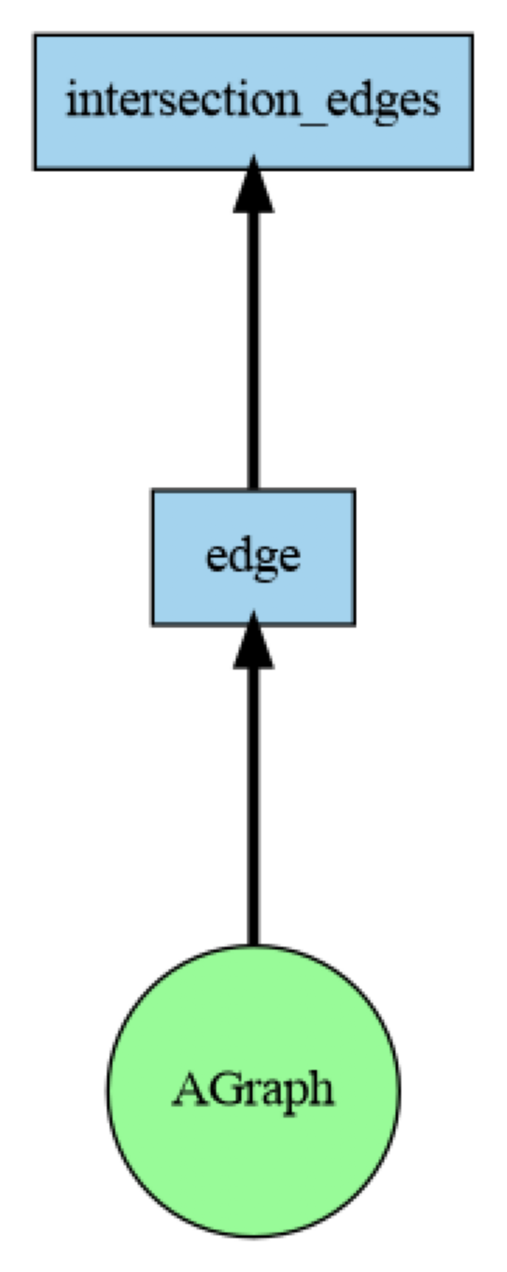

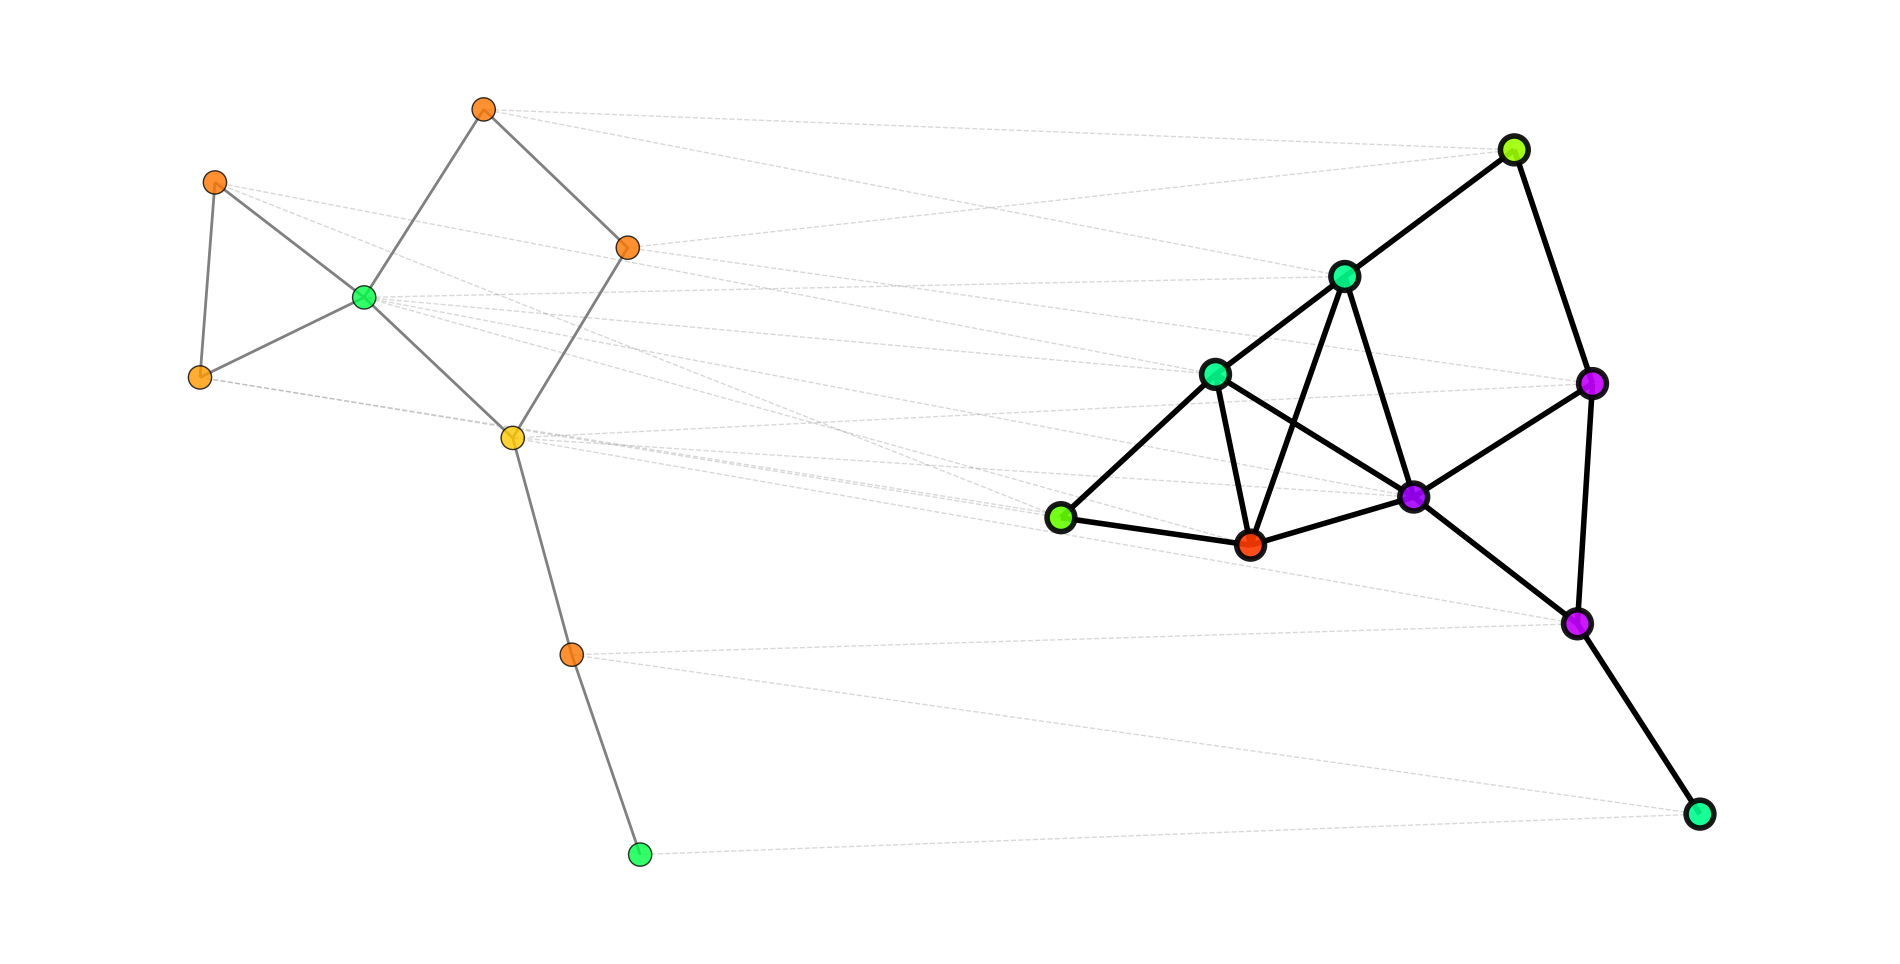

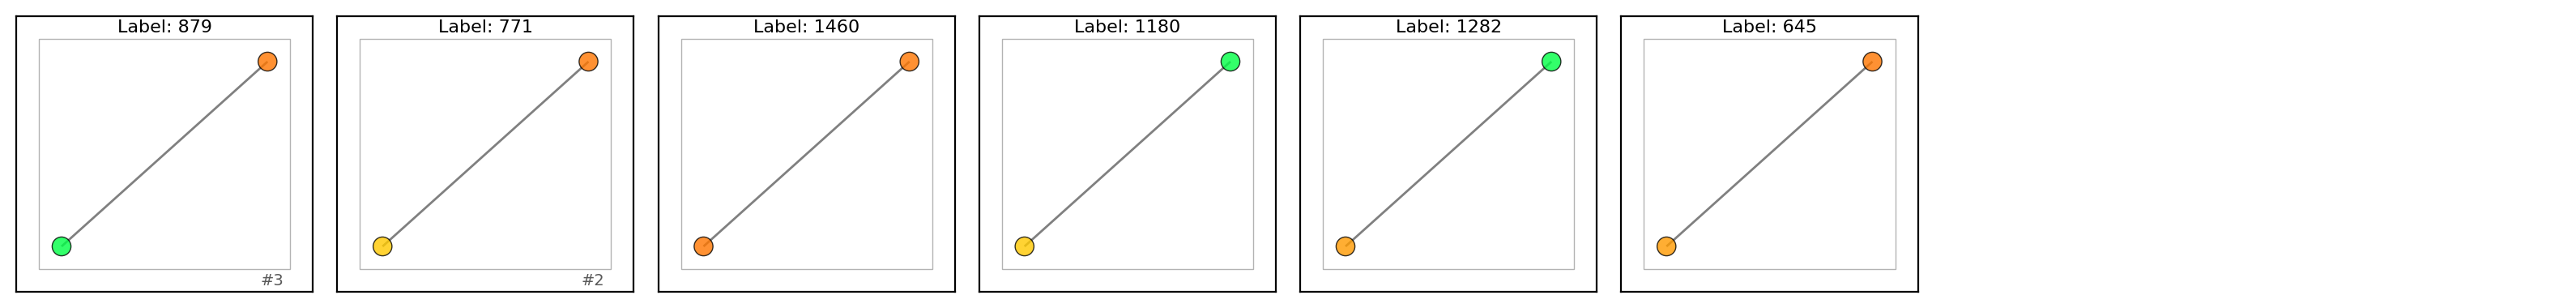

In [6]:
df = forward_compose(edge(), intersection_edges())
forward_node_ag = draw(graph, df)


## Order matters

The next pair uses a filter and a decomposition. These are not interchangeable.

`compose(filter_by_number_of_nodes(...), cycle())` means: find cycles first, then keep only 3-node cycles.

`forward_compose(filter_by_number_of_nodes(...), cycle())` means: filter the current interpretation graph first, then try to run `cycle()` on what remains.


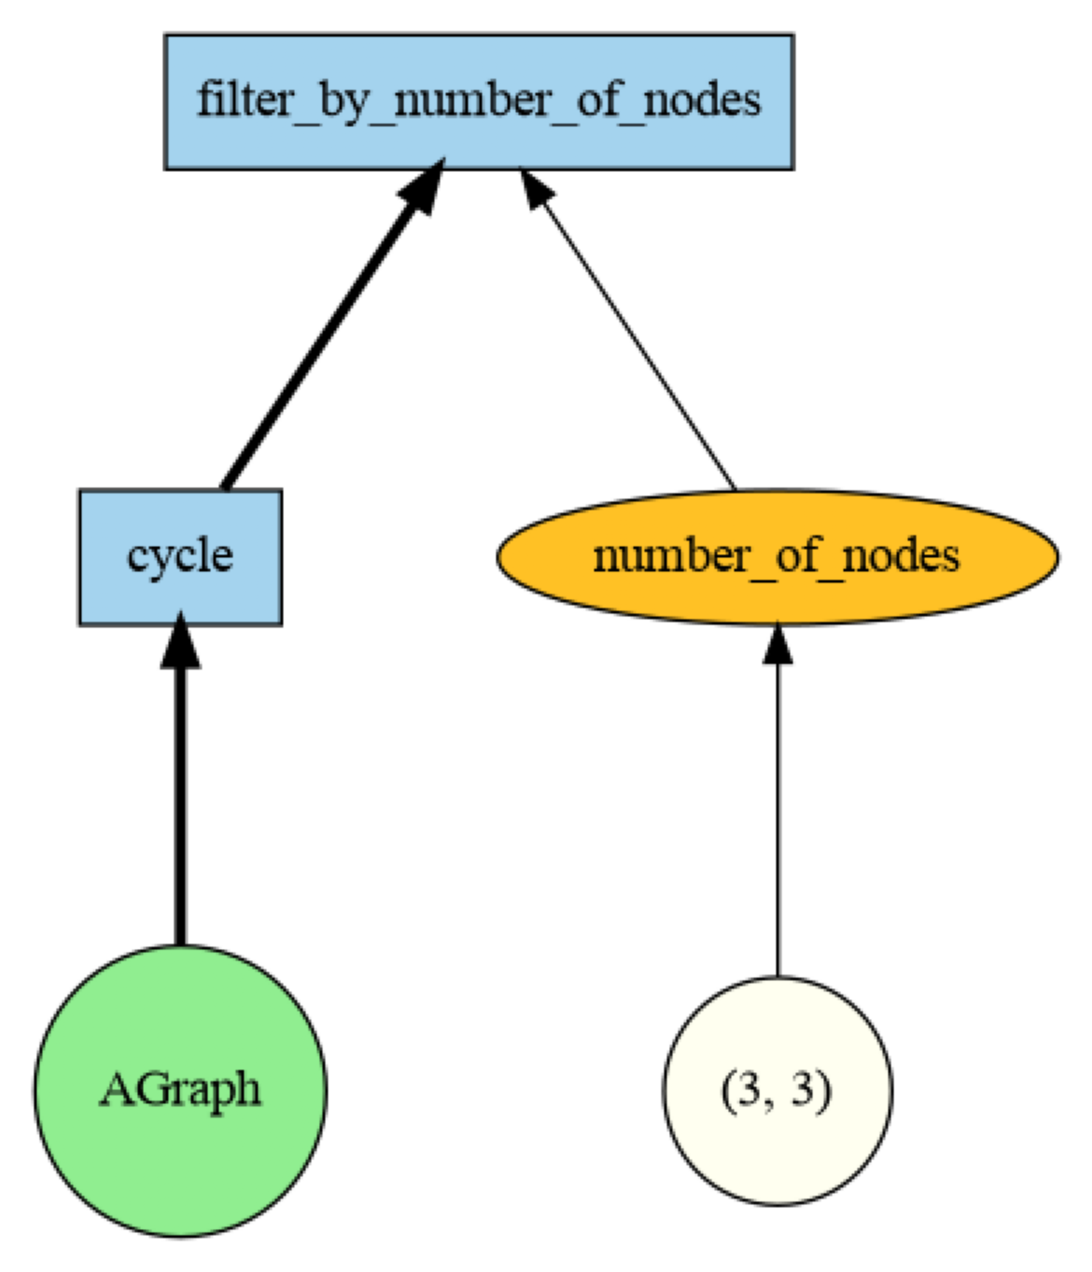

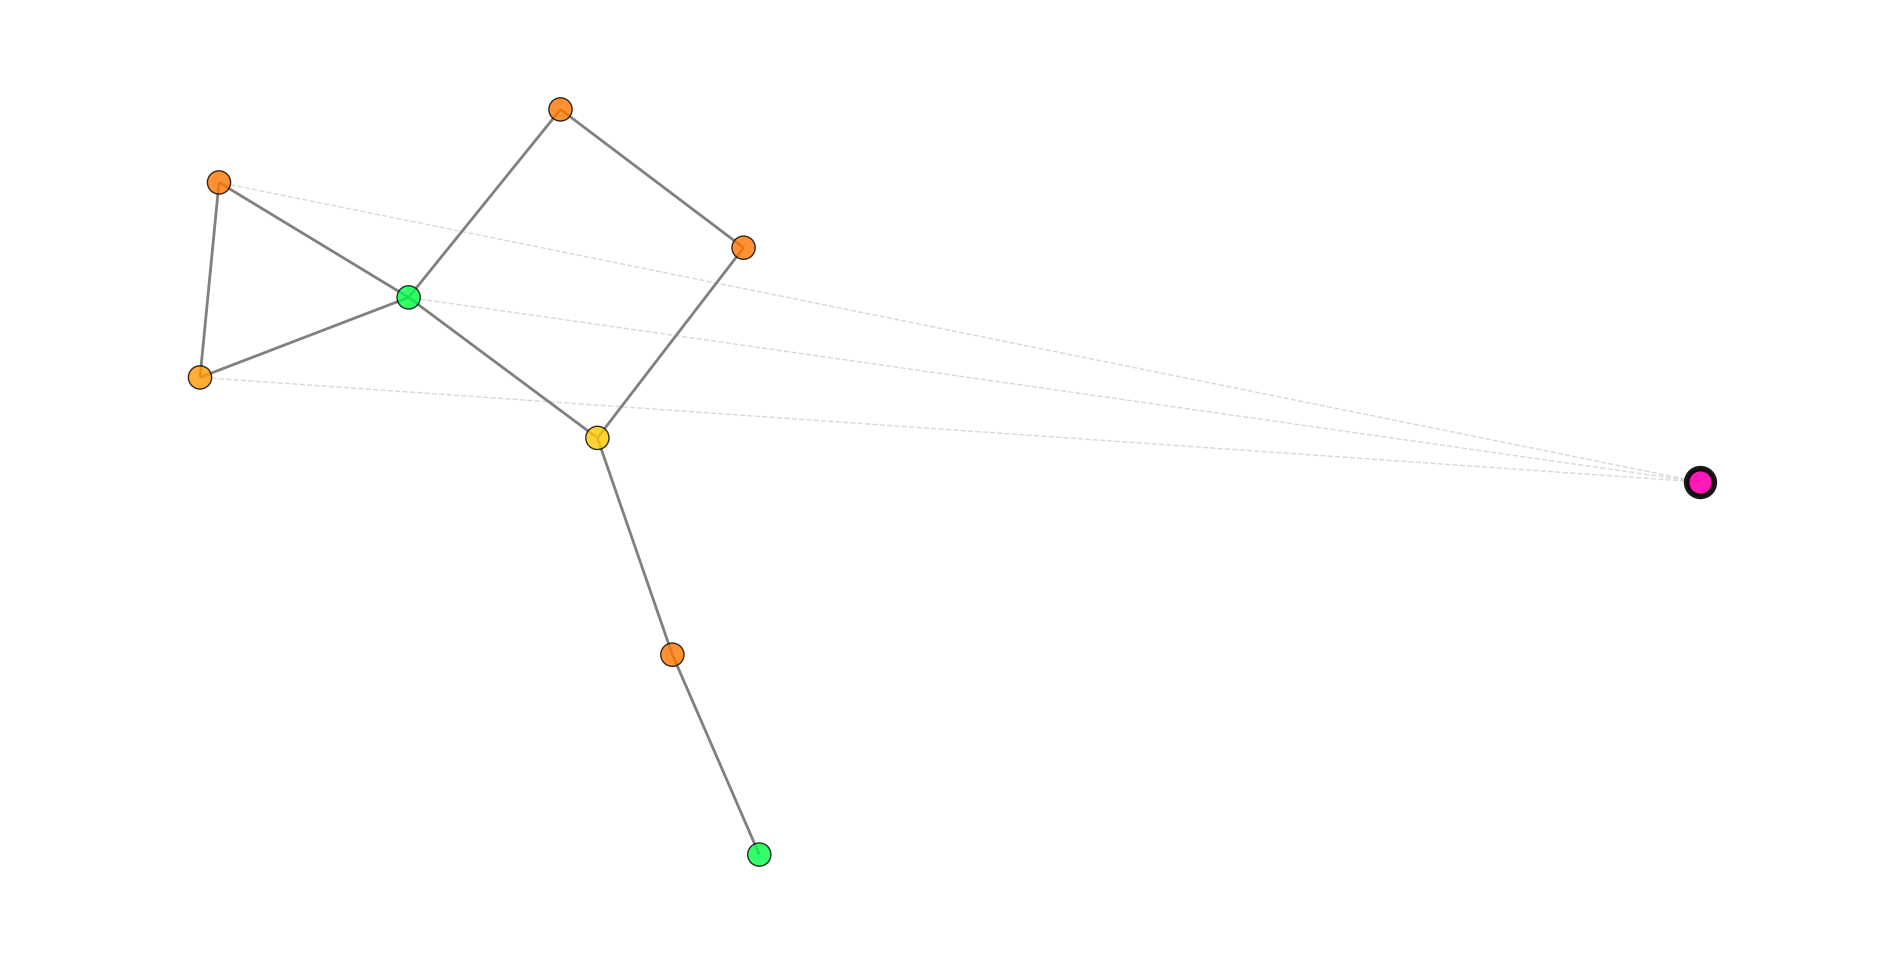

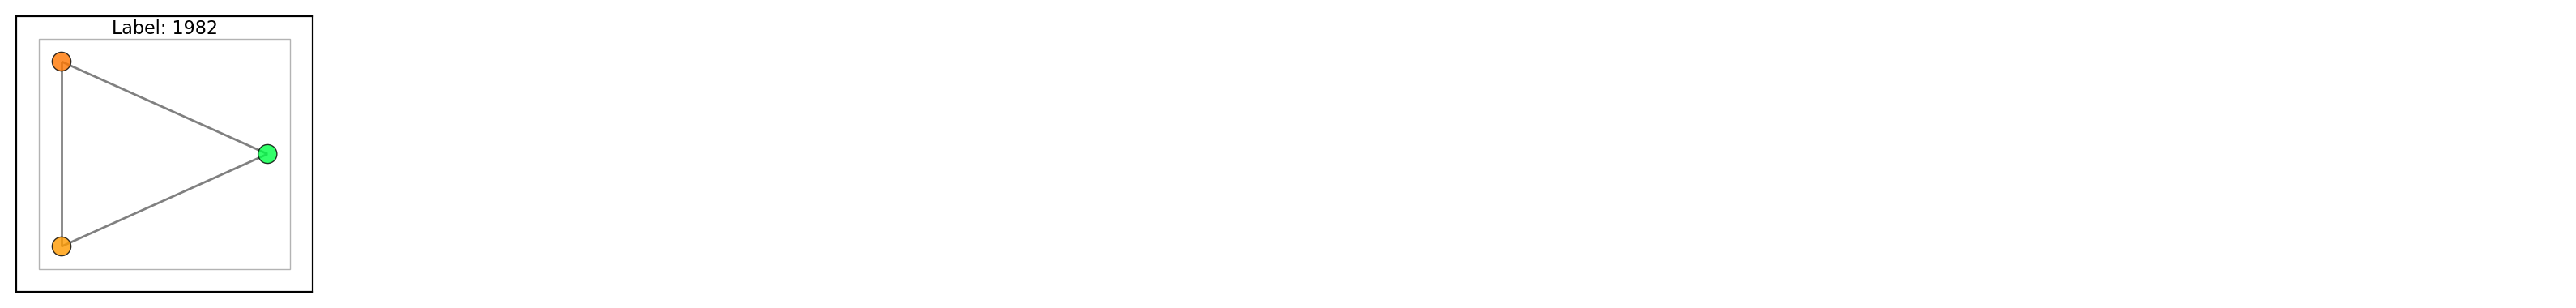

In [7]:
df = compose(filter_by_number_of_nodes(number_of_nodes=(3, 3)), cycle())
cycles_then_filter_ag = draw(graph, df)


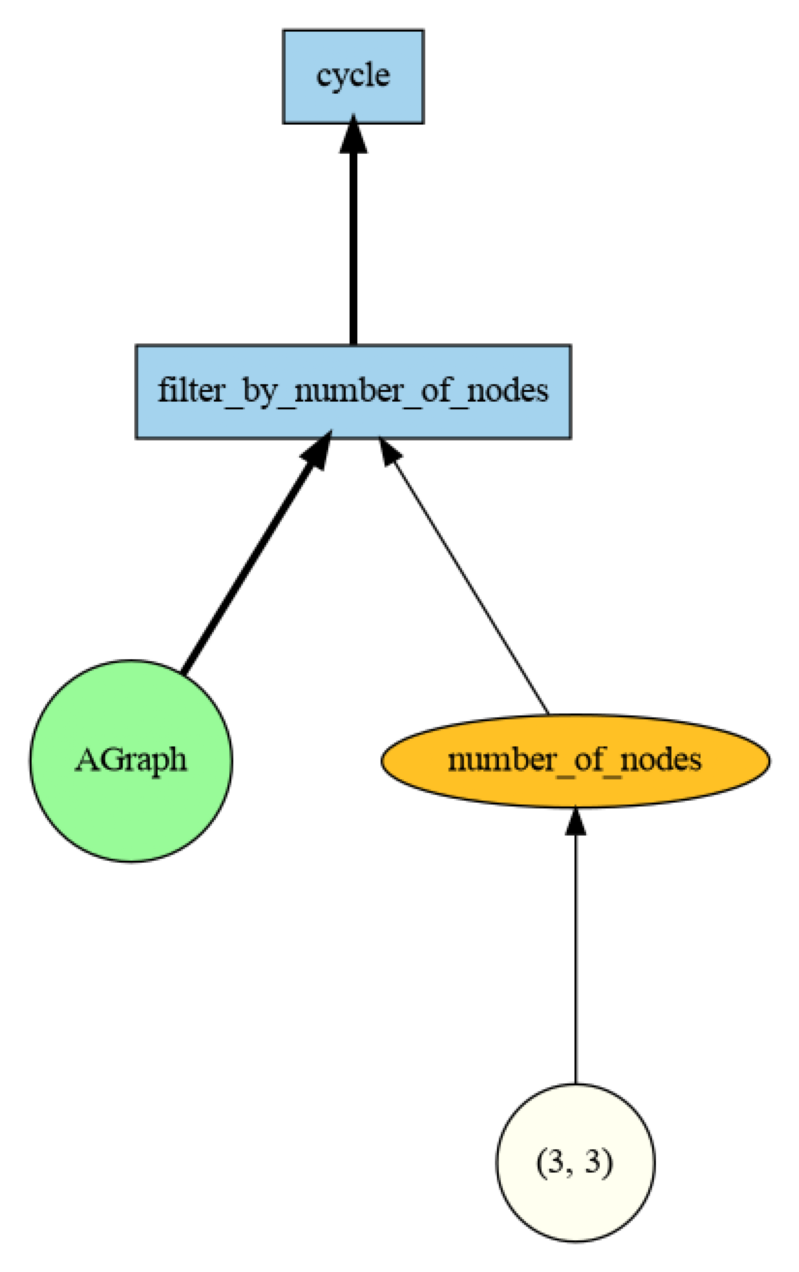

[display_mappings] Empty abstract graph — nothing to display.


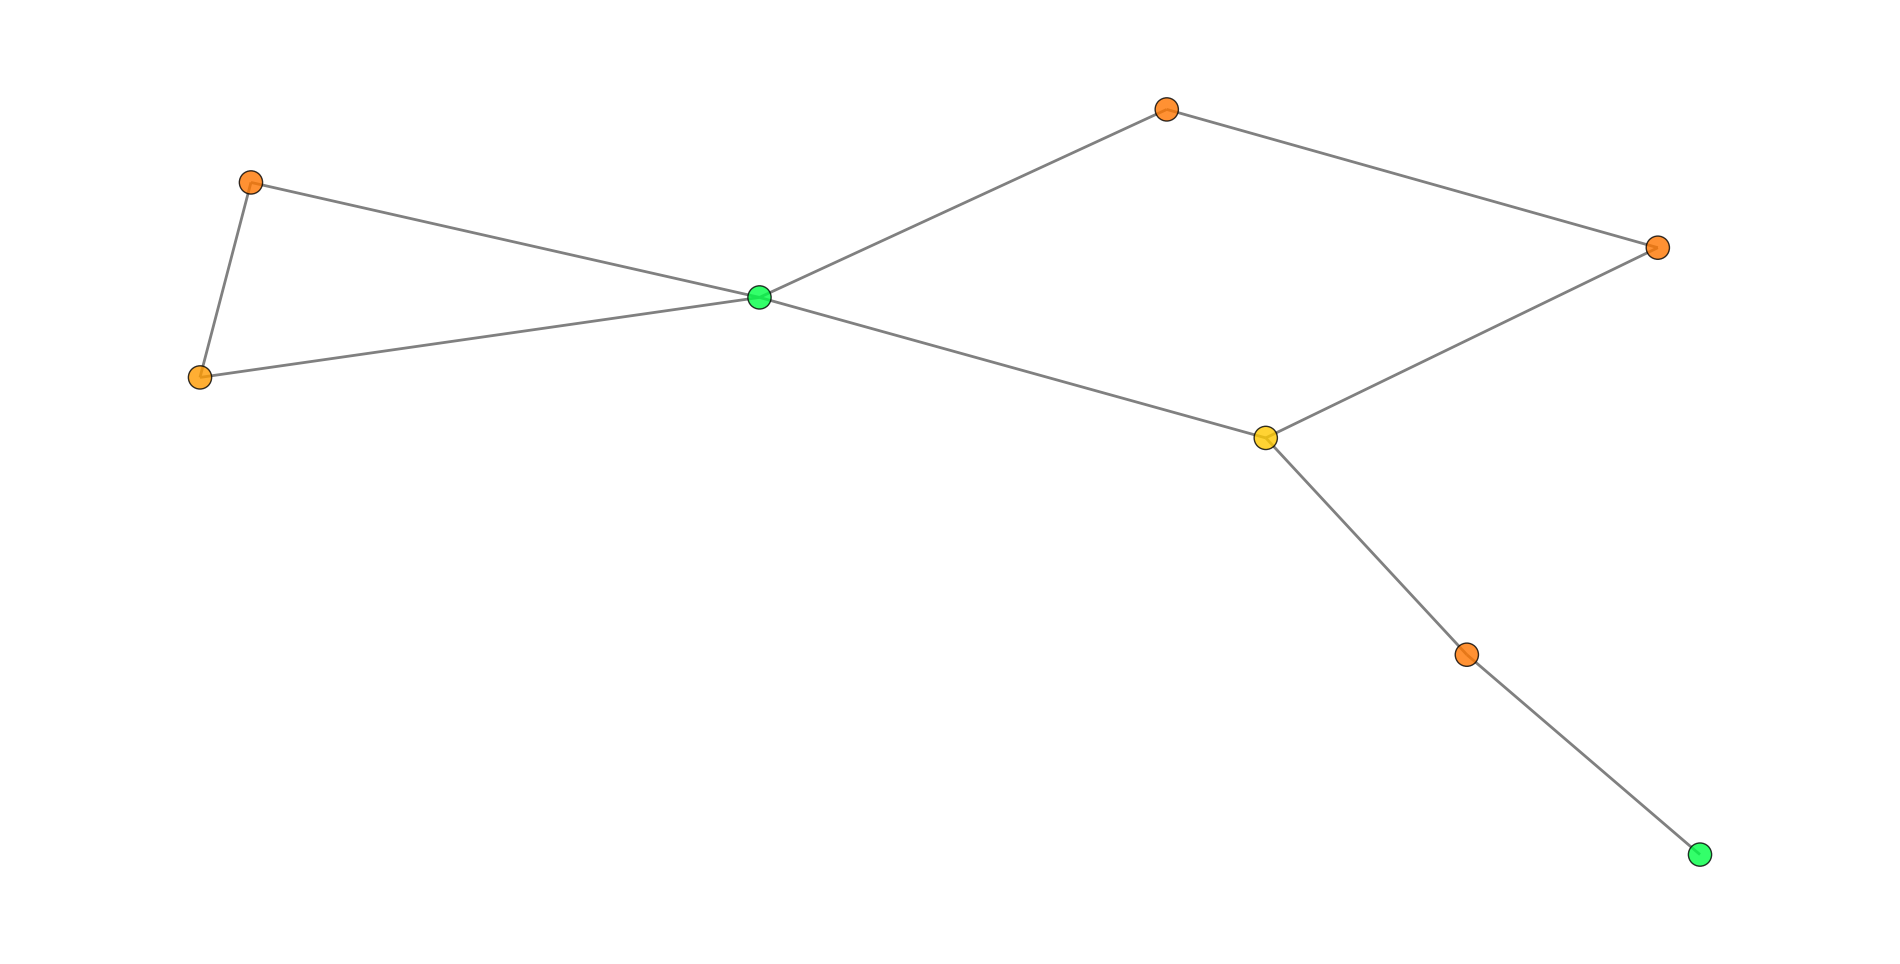

In [8]:
df = forward_compose(filter_by_number_of_nodes(number_of_nodes=(3, 3)), cycle())
filter_then_cycles_ag = draw(graph, df)


The difference above is the main reason to keep composition order explicit when building operator libraries. The pipeline is not just syntax. It changes the meaning of the decomposition.


## A longer composition

This next pipeline first builds radius-1 neighborhoods, then drops base-graph labels, and finally adds intersection-based edges in the interpretation graph. This is a typical pattern: decompose, normalize, then connect.


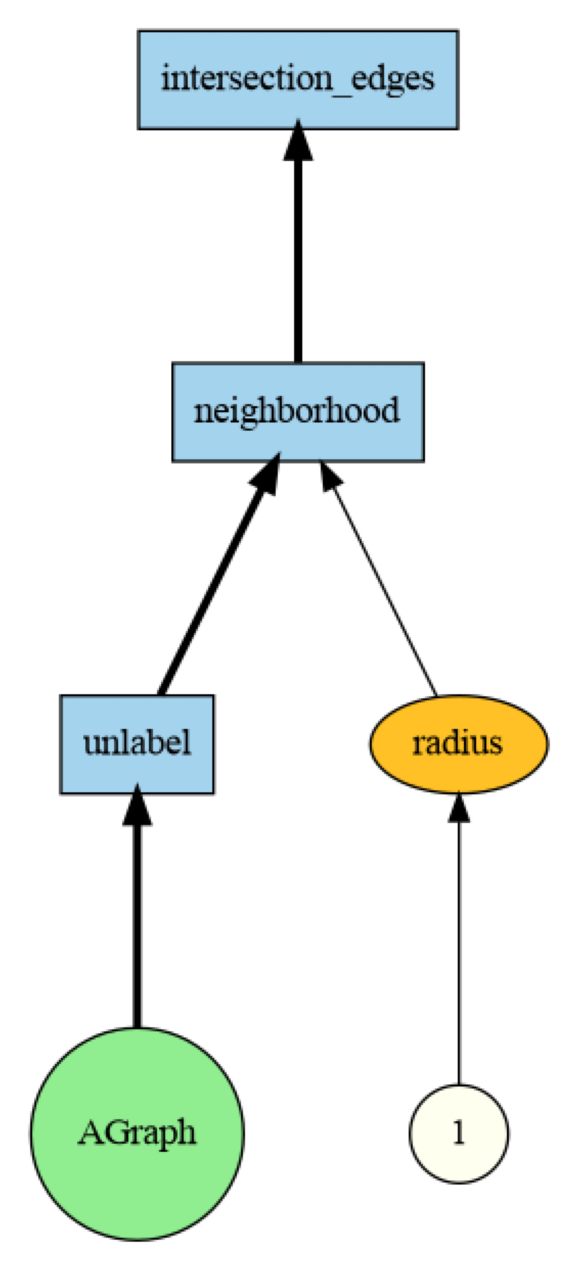

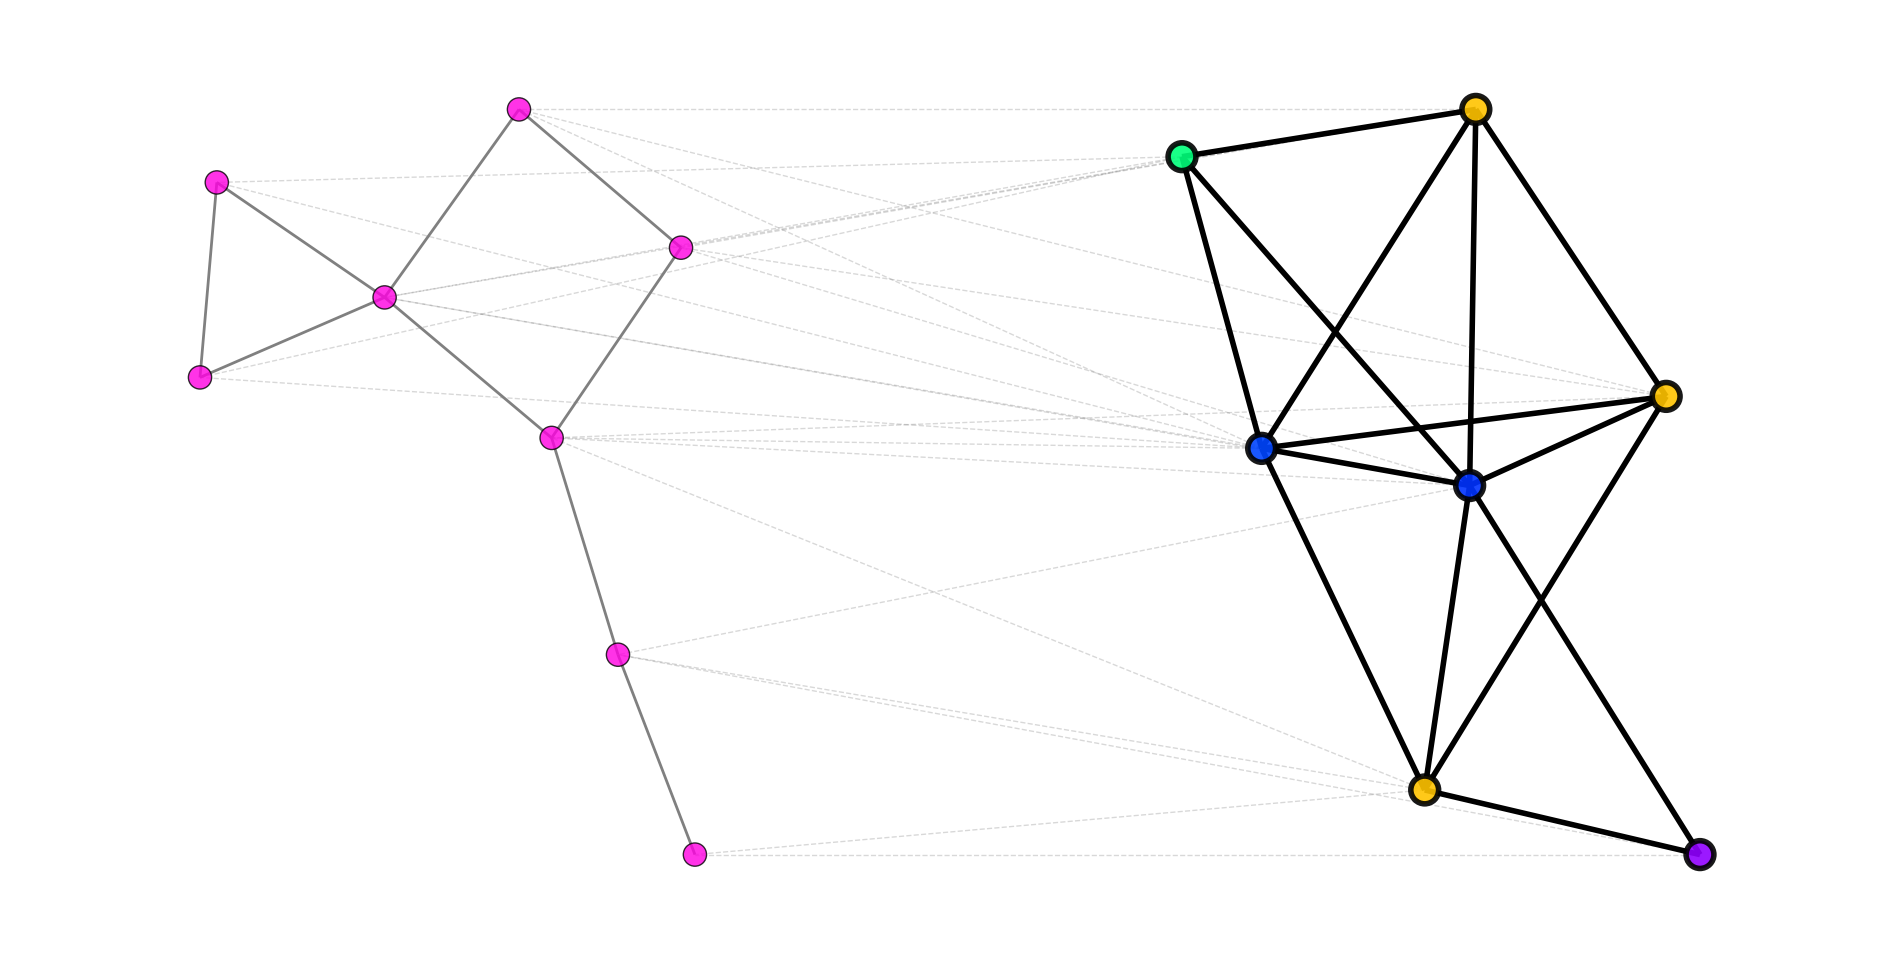

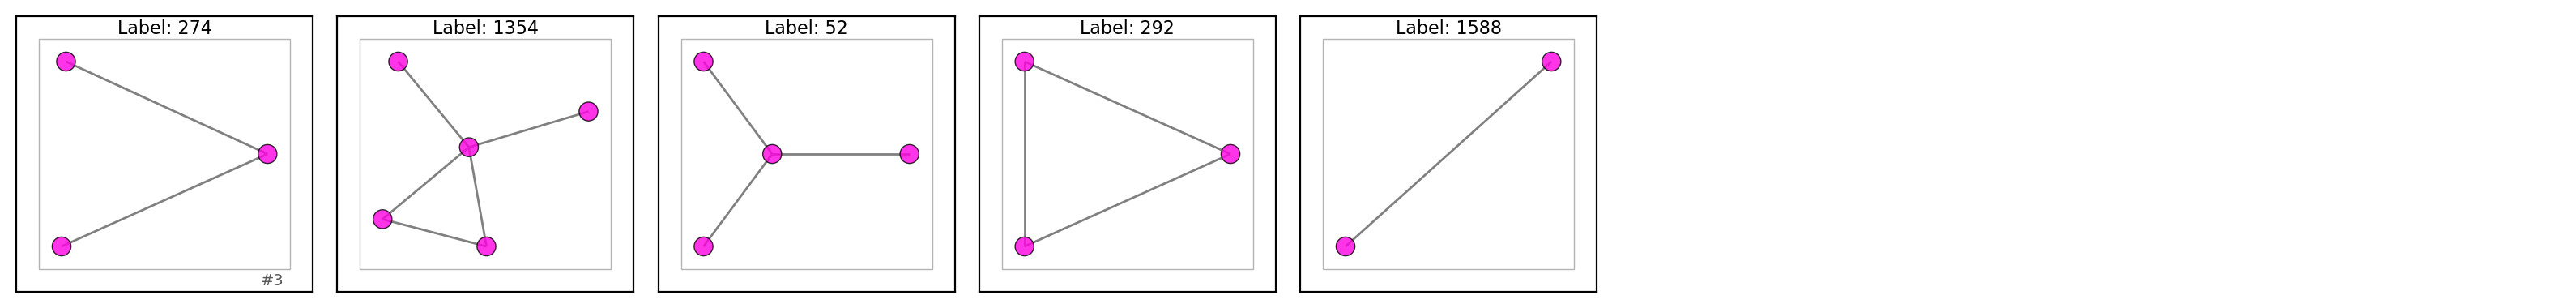

In [9]:
df = compose(intersection_edges(), neighborhood(radius=1), unlabel())
normalized_neighborhood_ag = draw(graph, df)


## `add(...)` unions multiple decompositions from the same input

`add(cycle(), tree())` does not feed one result into the other. Instead it runs both on the same input `AbstractGraph` and combines their interpretation nodes into one output graph.


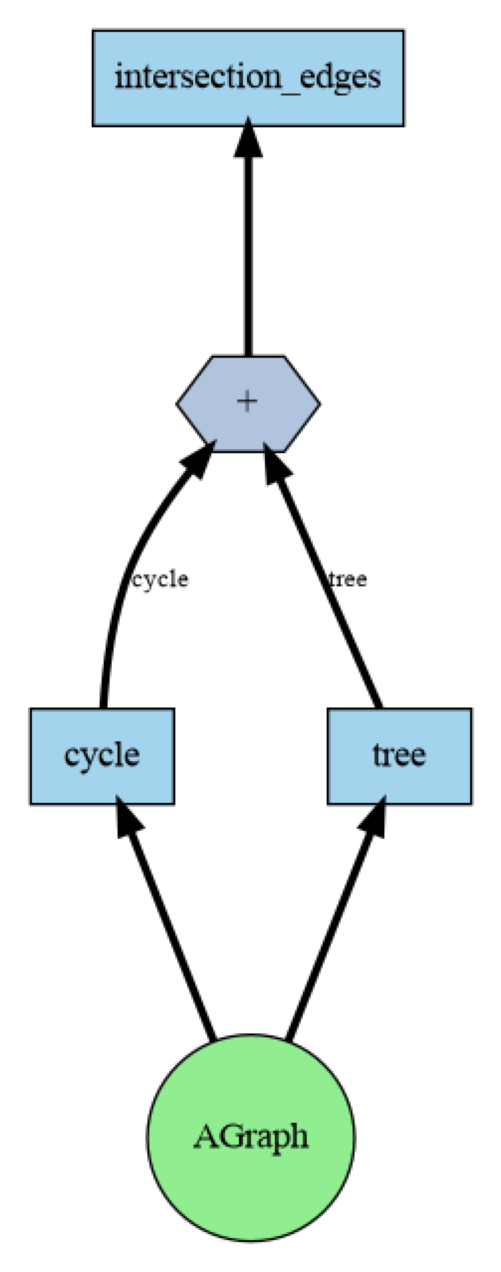

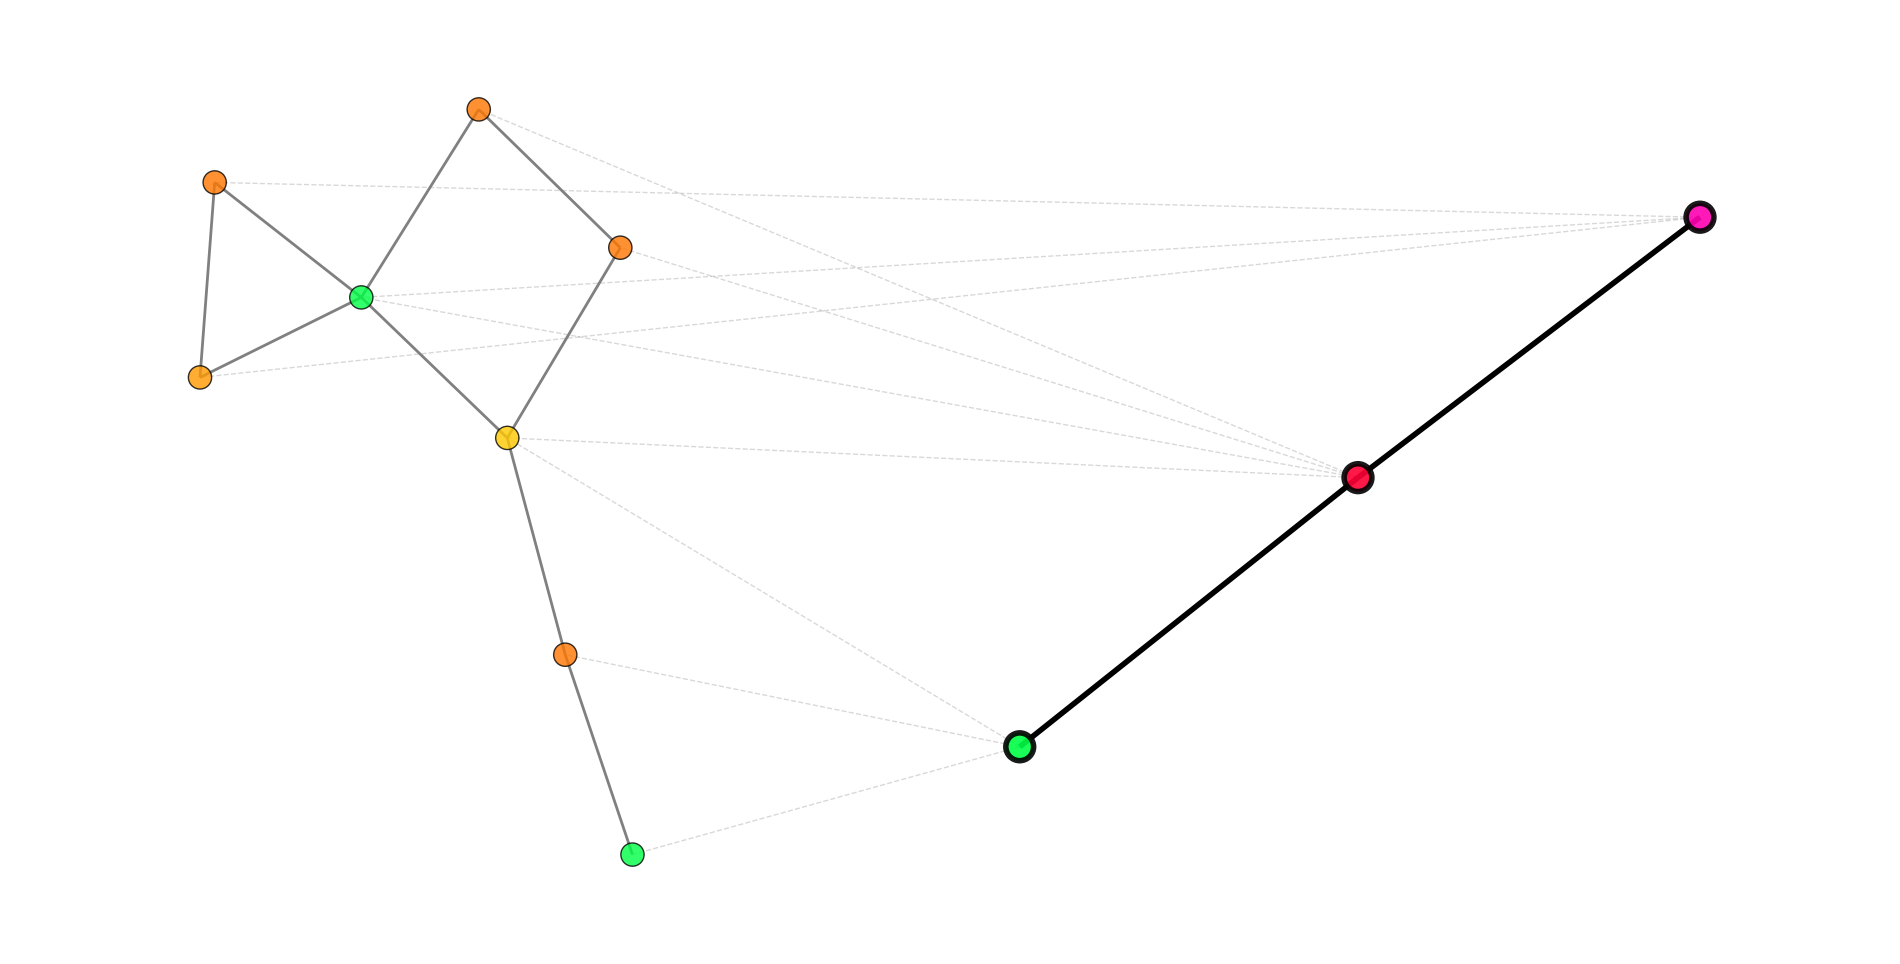

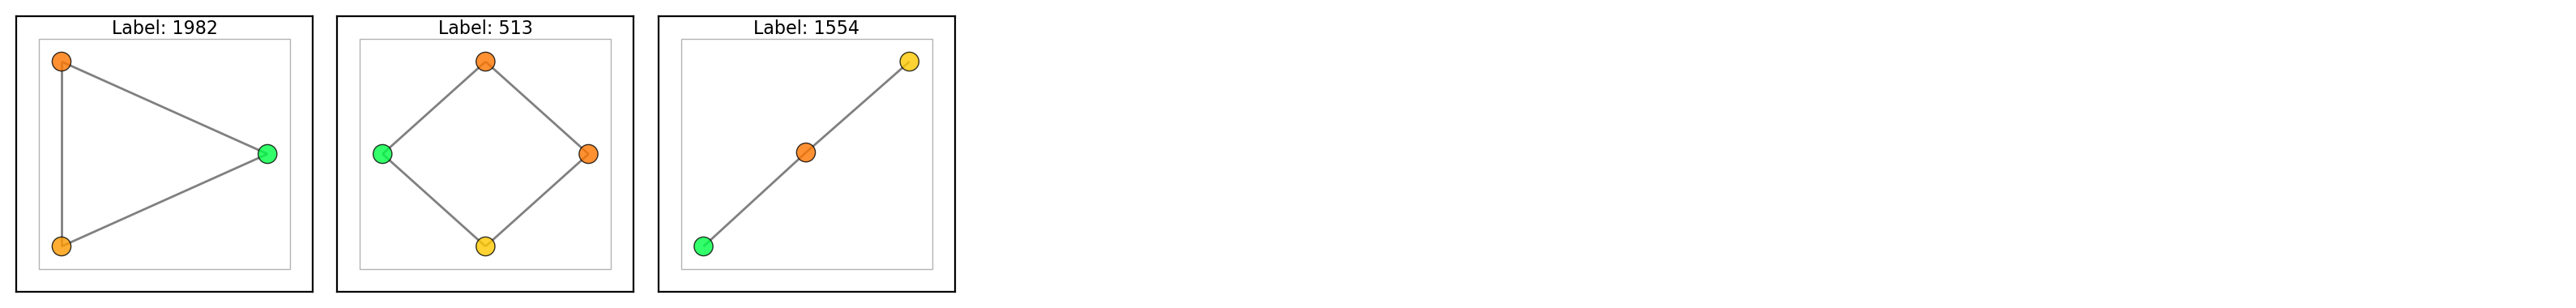

In [10]:
df = compose(intersection_edges(), add(cycle(), tree()))
cycle_tree_ag = draw(graph, df)


## `add(...)` can broaden the vocabulary

A simple way to make the interpretation graph richer is to include several granularities at once. Here we keep both singleton nodes and individual edges.


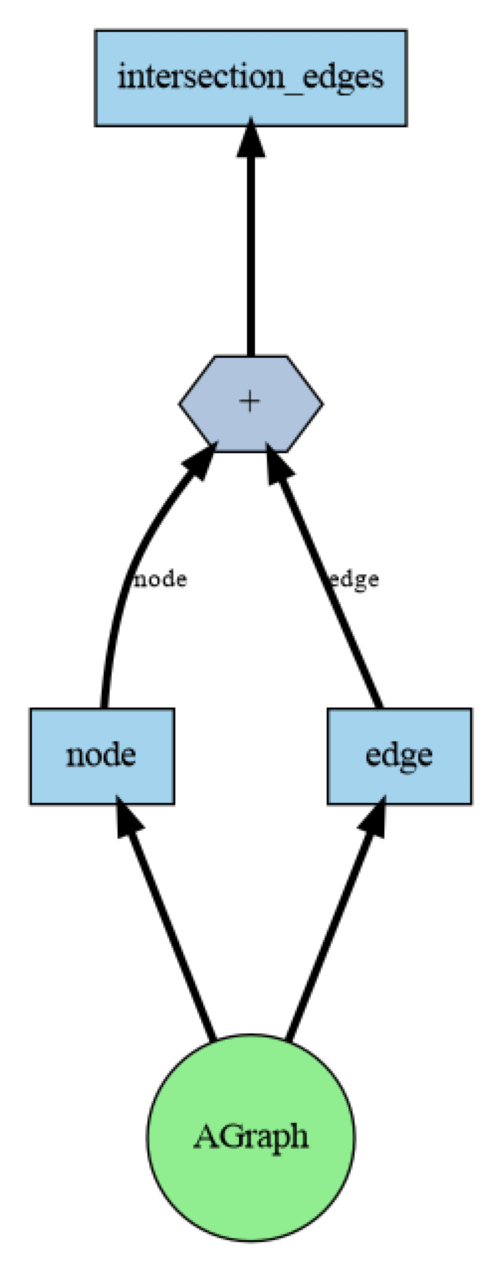

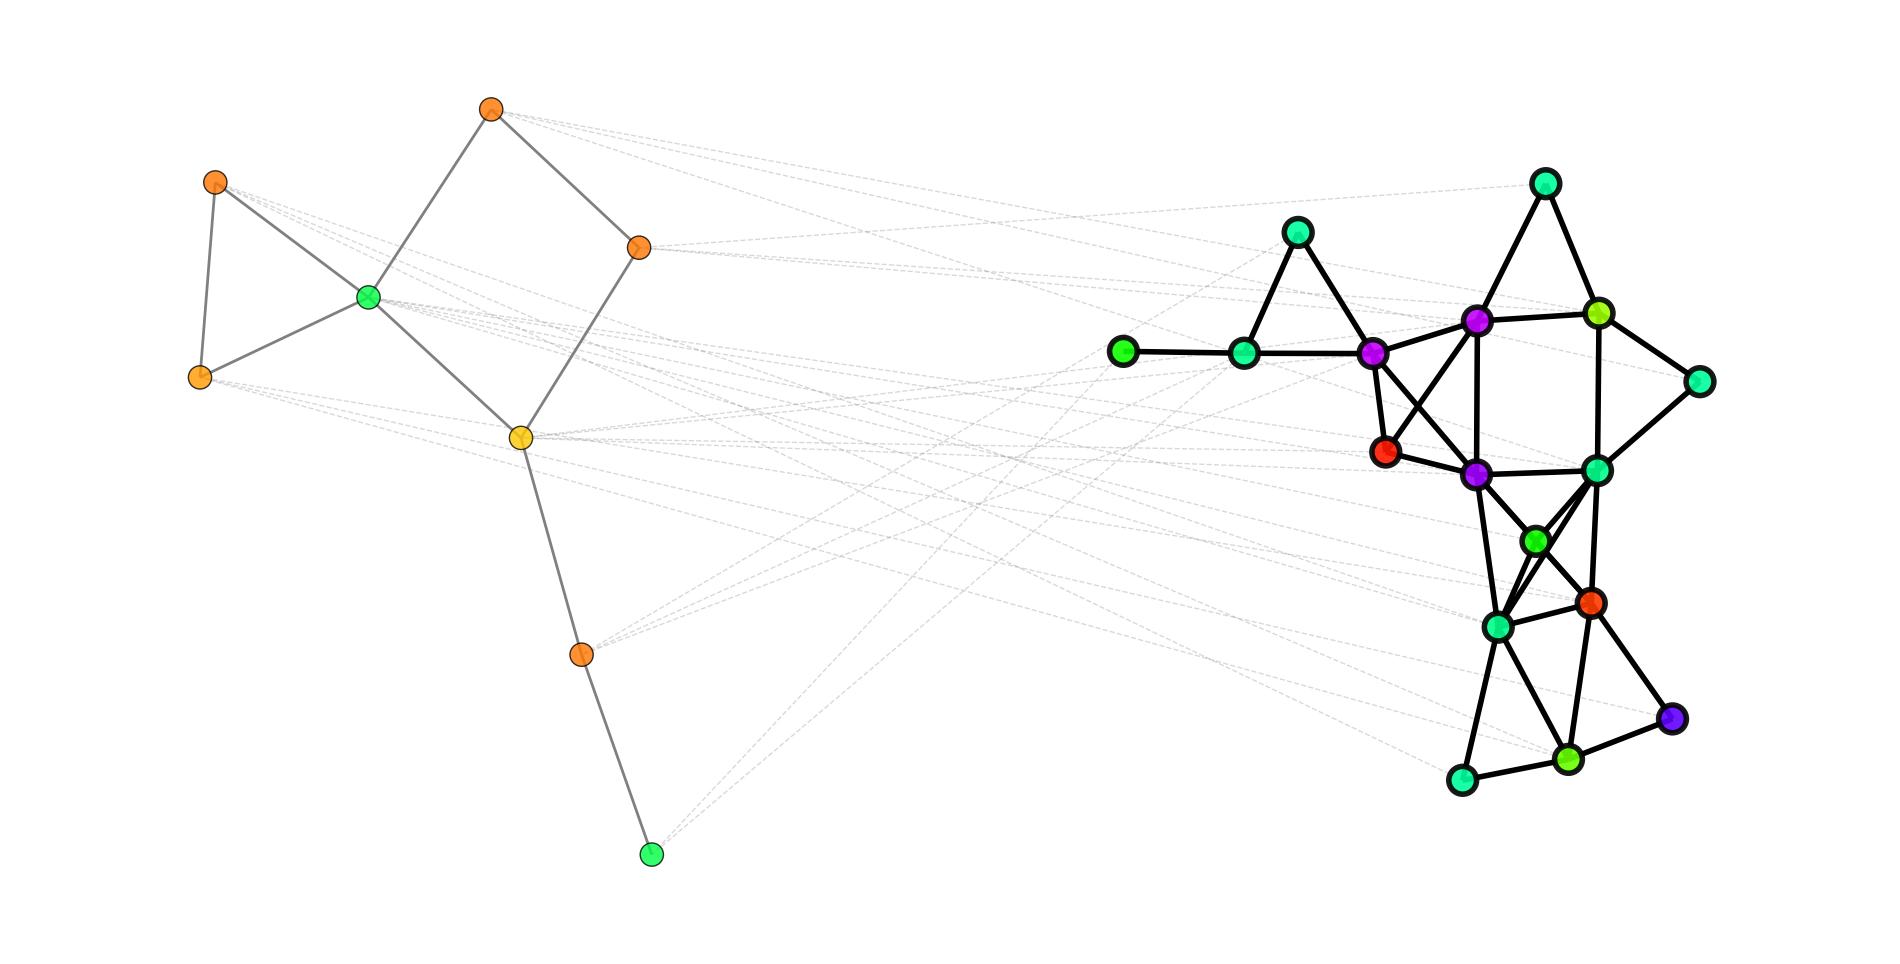

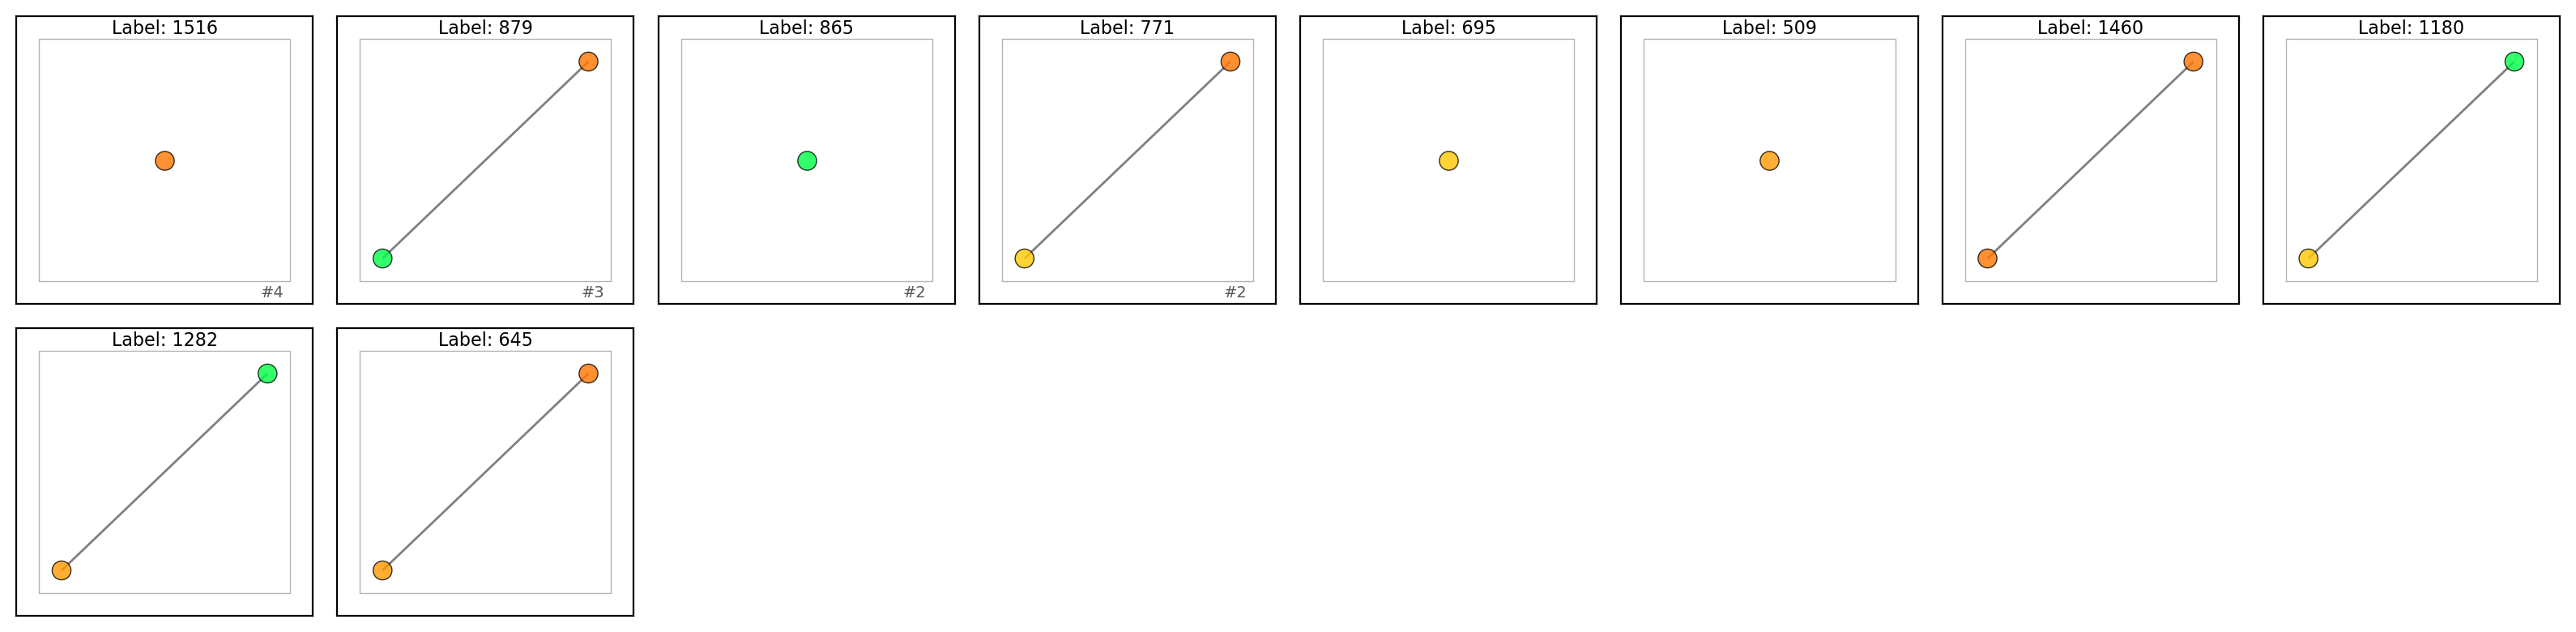

In [11]:
df = compose(intersection_edges(), add(node(), edge()))
node_edge_ag = draw(graph, df)


## `add(...)` can mix local and motif-style structure

The next example combines local neighborhoods with cycles. The result contains both broader local context and explicit motif nodes.


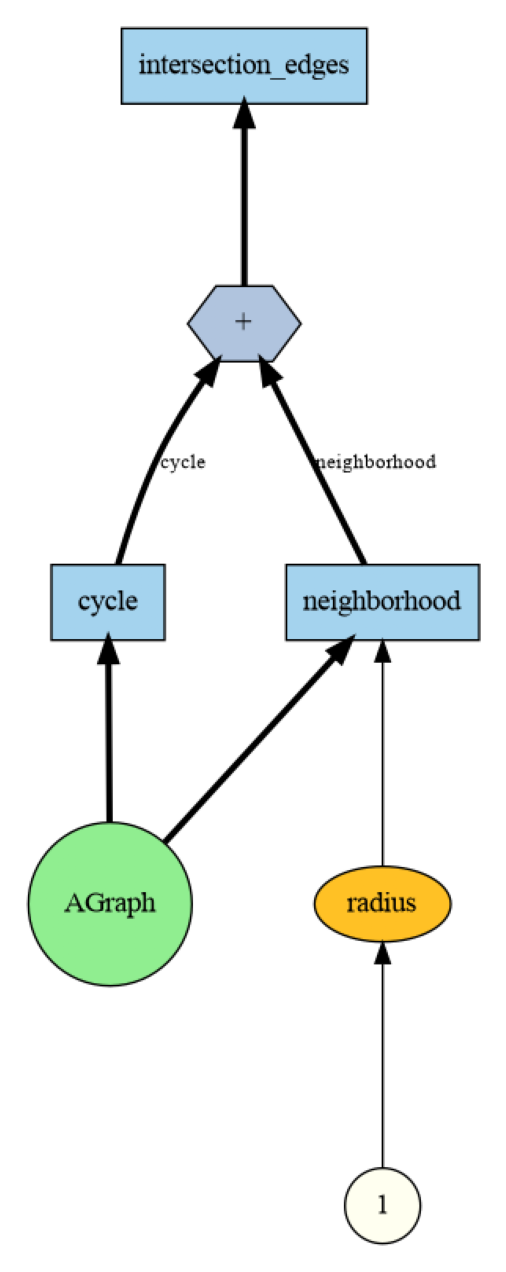

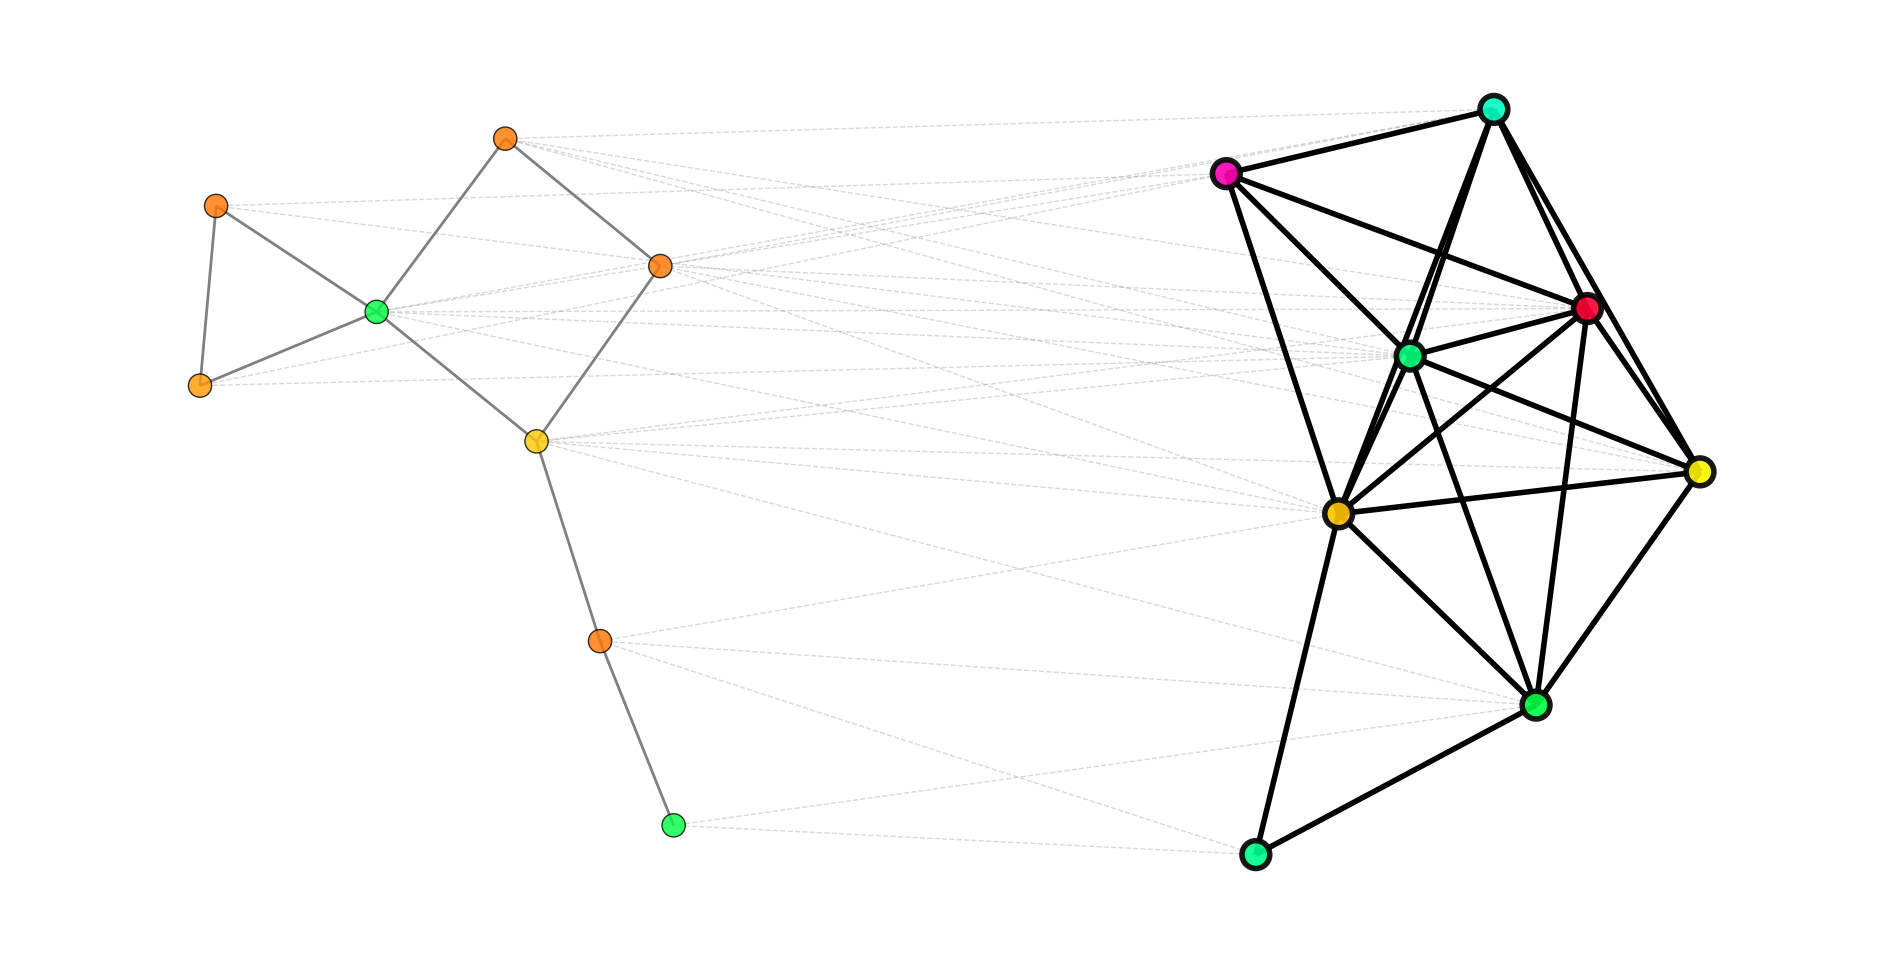

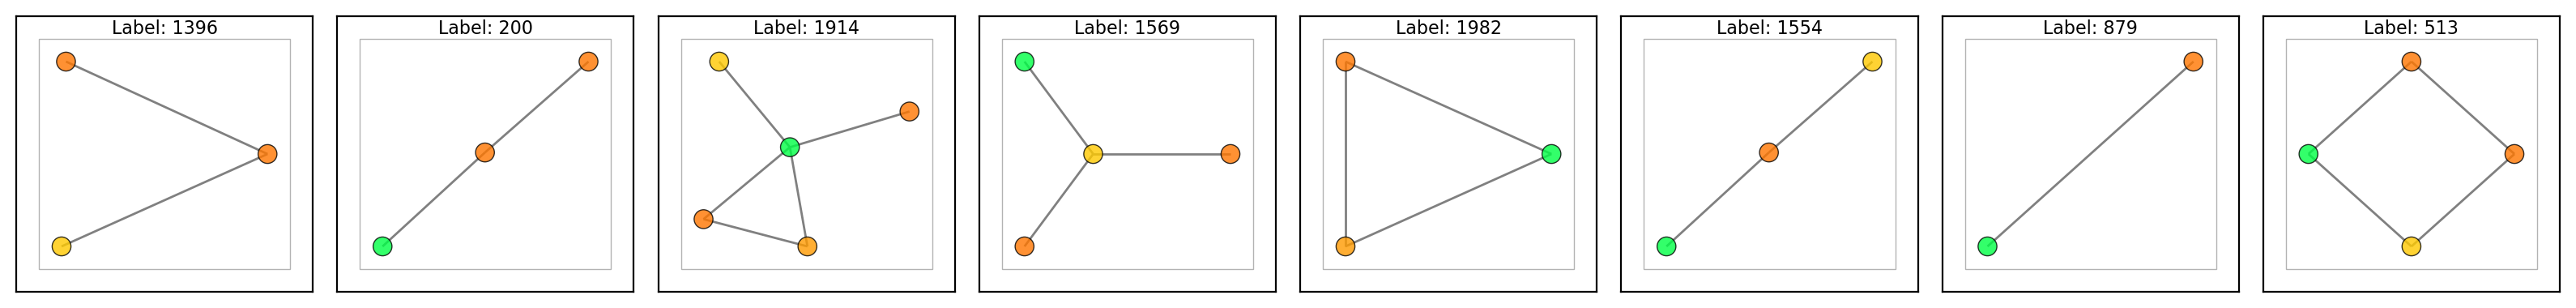

In [12]:
df = compose(intersection_edges(), add(neighborhood(radius=1), cycle()))
local_plus_cycle_ag = draw(graph, df)


## Summary

Unary decompositions define the pieces. Composition determines execution order. `add(...)` determines which decompositions contribute side by side to the final interpretation graph. Together, these give you the basic language for building reusable operator pipelines.

A natural next notebook is filtering and selection, where you keep only the parts of a decomposition that match structural constraints.

Previous: [01 Unary Decompositions](./example_abstract_graph_operators_01_unary_decompositions.ipynb)  
Next: [03 Merge And Complements](./example_abstract_graph_operators_03_merge_and_complements.ipynb)
